In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import func

In [40]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# x_train = func.downsize_mnist(x_train)
mean_train = x_train.mean(axis=0)
x_train = x_train - mean_train

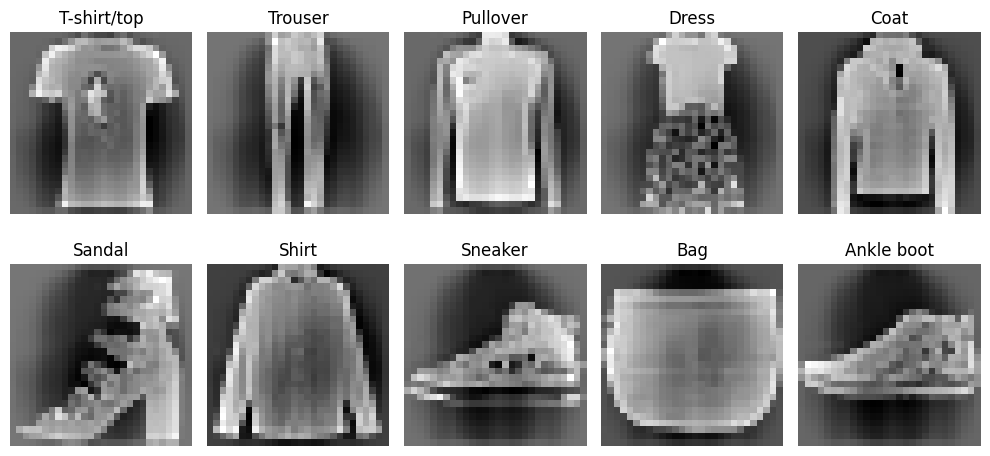

In [41]:
labels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    idx = np.random.choice(np.where(y_train == i)[0])
    axes[i//5, i%5].imshow(x_train[idx], cmap='gray')
    axes[i//5, i%5].set_title(labels[i])
    axes[i//5, i%5].axis('off')
plt.tight_layout()
plt.show()


## Images generated

In [42]:
_, d, _ = x_train.shape
x_train = x_train.reshape(len(x_train), -1)
cov_train = np.cov(x_train, rowvar=False)
sqrt_C = func.sqrt_mat(cov_train)

In [45]:
def generate_image():
    z = np.random.randn(d**2)
    x_gen = sqrt_C@z
    x_gen = x_gen.reshape(d,d)
    # return x_gen + mean_train
    return x_gen

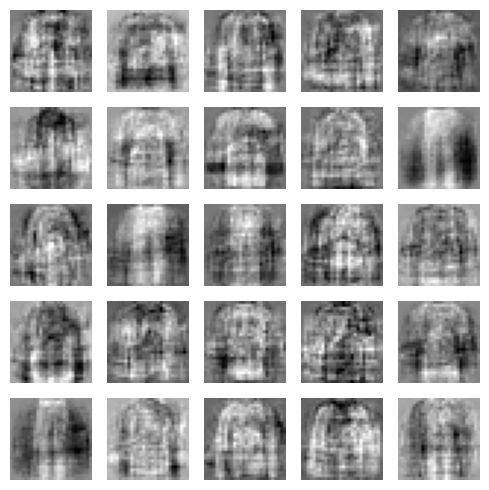

In [59]:
M = 5
fig, axes = plt.subplots(M, M, figsize=(M, M))
for i in range(M**2):
    axes[i//M, i%M].imshow(generate_image(), cmap='gray')
    axes[i//M, i%M].axis('off')
plt.tight_layout()